# Invoice Payment Risk Regression

## Project objective

Predict **days past due (`dpd_target`)** for invoices using customer, payment-history, invoice, and behavioural features.

This merged notebook compares two modelling strategies:

1. **Approach A — Regression on the original target**
2. **Approach B — Regression after Yeo–Johnson target transformation**

Both original notebooks are preserved so the modelling decisions and experiments remain visible.

> Place the required source files inside `data/` before running the notebook.

## Target

```text
dpd_target
```

The target represents the number of days an invoice is past due. This is a continuous regression problem.

# Approach A — Regression Without Target Transformation

## A1. Project title

### REGRESSION MODEL-INVOICE PAYMENT RISK MODEL

## A2. Imports

In [34]:
import pandas as pd
import numpy as np

## A3. Load training data

In [35]:
df_train=pd.read_csv("data/train_data_shuffle.csv")

## A4. Initial inspection

In [36]:
df_train.shape

(106197, 364)

In [37]:
pd.set_option('display.max_columns',None)

In [38]:
pd.set_option('display.max_rows',None)

In [39]:
df_train.sample(5)

,grace_period_dt,parentid_deposit_max_agg-single,closed_sum_balance_sliding_max_lag_6_1,totalamount_expanding_mean_lag_1,aws_id_inv,customerinvoicetotalpaid_sliding_sum_lag_3_1,customerinvoicebalance_lag_1,val_late,closed_sum_total_paid_sliding_max_lag_6_1,parentid_customerid_payment_totalamount_skewness_agg-single,customerinvoicetotalpaid_expanding_mean_lag_1,outstanding_flag_expanding_mean_lag_1,avg_days_early,parentid_deposit_min_agg-single,open_sum_deposit_sliding_sum_lag_3_1,nr_late_nr_paid_ratio,customerinvoicedeposit_sliding_mean_lag_3_1,open_sum_totalamount_sliding_mean_lag_6_1,open_sum_totalamount_sliding_max_lag_3_1,customerinvoicedeposit_sliding_mean_lag_6_1,parentid_payment_totalamount_min_agg-single,customerinvoicetotalamount_sliding_sum_lag_6_1,closed_sum_total_paid_sliding_mean_lag_3_1,parentid_customerid_balance_max_agg-single,pay_freq,customerinvoicecount,open_sum_total_paid,closed_sum_balance_expanding_min_lag_1,per_win_completion_dt,customerinvoicebalance,closed_sum_total_paid_sliding_sum_lag_6_1,closed_sum_totalamount_sliding_max_lag_3_1,outstanding_flag_sliding_sum_lag_3_1,dpd_reg_date,closed_sum_balance_sliding_mean_lag_3_1,open_sum_deposit_sliding_min_lag_6_1,open_sum_balance_sliding_min_lag_6_1,past_dso_6m_sliding_min_lag_6_1,customerinvoicedeposit_sliding_sum_lag_6_1,open_sum_totalamount_sliding_mean_lag_3_1,customerinvoicebalance_expanding_max_lag_1,open_sum_deposit_expanding_min_lag_1,parentid_totalamount_max_agg-single,nr_early_nr_paid_ratio,parentid_deposit_sum_agg-single,past_dso_6m_expanding_max_lag_1,open_sum_total_paid_expanding_max_lag_1,nr_early,closed_sum_totalamount_sliding_min_lag_3_1,closed_sum_deposit_expanding_sum_lag_1,customerinvoicecount_sliding_max_lag_6_1,customerinvoicecount_sliding_sum_lag_6_1,customerinvoicetotalpaid_expanding_min_lag_1,invoice_date,customerinvoicebalance_sliding_sum_lag_3_1_customerinvoicetotalamount_sliding_sum_lag_3_1_ratio,nr_late,balance_agg,open_sum_total_paid_sliding_min_lag_6_1,customerinvoicecount_expanding_mean_lag_1,parentid_customerid_deposit_mean_agg-single,open_sum_balance_expanding_max_lag_1,open_sum_balance_sliding_sum_lag_3_1,parentid_totalamount_min_agg-single,past_dso_3m_sliding_sum_lag_6_1,customerinvoicetotalamount_expanding_min_lag_1,outstanding_flag_sliding_sum_lag_6_1,min_days_early,customerinvoicetotalamount_sliding_min_lag_6_1,past_dso_3m_sliding_max_lag_6_1,past_dso_6m,open_sum_totalamount_sliding_sum_lag_3_1,avg_days_late,closed_sum_totalamount_lag_1,customerinvoicedeposit_sliding_sum_lag_3_1,parentid_totalamount_mean_agg-single,customerinvoicedeposit_expanding_min_lag_1,past_dso_3m_expanding_min_lag_1,closed_sum_balance_sliding_min_lag_3_1,open_sum_balance_sliding_min_lag_3_1,customerinvoicecount_lag_1,customerinvoicebalance_sliding_sum_lag_6_1,customerinvoicecount_sliding_sum_lag_3_1,past_dso_6m_sliding_mean_lag_3_1,open_sum_total_paid_expanding_mean_lag_1,max_days_late,past_dso_3m_expanding_sum_lag_1,parentid_payment_totalamount_sum_agg-single,parentid_customerid_interaction,closed_sum_deposit_sliding_sum_lag_6_1,val_early_val_paid_ratio,customerinvoicetotalamount_sliding_min_lag_3_1,customerinvoicetotalamount_expanding_mean_lag_1,customerinvoicetotalpaid_sliding_mean_lag_6_1,parentid_customerid_deposit_skewness_agg-single,closed_sum_deposit_expanding_min_lag_1,customerinvoicedeposit_expanding_max_lag_1,closed_sum_total_paid_expanding_mean_lag_1,outstanding_flag_sliding_mean_lag_6_1,closed_sum_deposit_expanding_mean_lag_1,dummy,nr_out_late,closed_sum_total_paid_sliding_sum_lag_3_1,customerinvoicecount_expanding_min_lag_1,total_paid,customerinvoicetotalamount_sliding_max_lag_6_1,closed_sum_total_paid_expanding_sum_lag_1,past_dso_6m_sliding_max_lag_3_1,parentid_totalamount_sum_agg-single,open_sum_deposit_sliding_max_lag_3_1,parentid_totalamount_stddev_agg-single,customerinvoicetotalamount_sliding_mean_lag_6_1,past_dso_6m_sliding_mean_lag_6_1,past_dso_6m_lag_1,open_sum_totalamount_sliding_sum_lag_6_1,paidinfulldate,closed_sum_deposit_

In [40]:
df_train['dpd_target'].nunique()

367

In [41]:
date_cols = [
    'invoice_date',
    'first_inv_date',
    'paidinfulldate',
    'grace_period_dt',
    'per_win_completion_dt',
    'dpd_reg_date',
    'date',
    'inv_created_ym',
    'max_inv_dt',
    'max_inv_ym',
    'inv_ym',
    'final_date',
    'dummy_inv_inv_created_dt_max_agg-single',
    'dummy_inv_ym_max_agg-single',
    'currentdate',
    'inv_created_dt',
    'duedate',
    'explodeDate',
    'dpd_final_date',

    # Engineered date features
    'inv_created_dt_weekend_date-func',
    'inv_created_dt_month_date-func',
    'inv_created_dt_dayofyear_date-func',
    'inv_created_dt_dayofweek_date-func',
    'inv_created_dt_dayofmonth_date-func',
    'inv_created_dt_quarter_date-func',
    'inv_created_dt_week_date-func',

    'ddate_week',
    'ddate_quarter',
    'ddate_year',
    'ddate_dayofmonth',
    'ddate_dayofweek',
    '_ddate_dayofyear',
    'ddate_month',
    'ddate_weekend',
]

## A5. Remove identifier variables

### ID COLS

In [42]:
id_cols = [
    'customerid',
    'parentid',
    'invoiceheaderid',
    'invoiceheaderid_old',
    'aws_id_inv',
    'parentid_customerid_interaction',
    'parentid_customerid_interaction_inv_ym_interaction'
]

In [43]:
id_summary = pd.DataFrame({
    'nunique': df_train[id_cols].nunique(),
    'missing_count': df_train[id_cols].isnull().sum(),
    'missing_pct': (df_train[id_cols].isnull().sum() / len(df_train) * 100).round(2),
    'total_rows': len(df_train),
    'dtype': df_train[id_cols].dtypes
})

id_summary['unique_pct'] = (id_summary['nunique'] / id_summary['total_rows'] * 100).round(2)

print(id_summary)

                                                    nunique  missing_count  \
customerid                                            22647              0   
parentid                                                186              0   
invoiceheaderid                                      106197              0   
invoiceheaderid_old                                  106197              0   
aws_id_inv                                           106197              0   
parentid_customerid_interaction                       22647              0   
parentid_customerid_interaction_inv_ym_interaction   106197              0   

                                                    missing_pct  total_rows  \
customerid                                                  0.0      106197   
parentid                                                    0.0      106197   
invoiceheaderid                                             0.0      106197   
invoiceheaderid_old                                        

In [44]:
df_train[date_cols].sample(5)

,invoice_date,first_inv_date,paidinfulldate,grace_period_dt,per_win_completion_dt,dpd_reg_date,date,inv_created_ym,max_inv_dt,max_inv_ym,inv_ym,final_date,dummy_inv_inv_created_dt_max_agg-single,dummy_inv_ym_max_agg-single,currentdate,inv_created_dt,duedate,explodeDate,dpd_final_date,inv_created_dt_weekend_date-func,inv_created_dt_month_date-func,inv_created_dt_dayofyear_date-func,inv_created_dt_dayofweek_date-func,inv_created_dt_dayofmonth_date-func,inv_created_dt_quarter_date-func,inv_created_dt_week_date-func,ddate_week,ddate_quarter,ddate_year,ddate_dayofmonth,ddate_dayofweek,_ddate_dayofyear,ddate_month,ddate_weekend
9688,2024-07-26T00:00:00.000Z,2024-05-17T00:00:00.000Z,2024-10-16,2024-11-23,2024-11-01,2024-10-16 00:00:00+00:00,2024-07-26T00:00:00.000Z,2024-07-01,2027-09-01,2027-11-01,2024-07-01,2024-10-16T00:00:00.000Z,2027-12-01T00:00:00.000Z,2027-12-01T00:00:00.000Z,2025-08-22T00:00:00.000Z,2024-07-26T00:00:00.000Z,2024-08-25T00:00:00.000Z,NaN,NaN,0,July,208_dayofyear,6_dayofweek,26_dayofmonth,3_quarter,30_week,34_week,3_quarter,2024_year,25_dayofmonth,1_dayofweek,238_dayofyear,August,1
9883,2024-07-24T00:00:00.000Z,2021-03-02T00:00:00.000Z,NaN,2024-11-06,2024-11-01,2024-11-08 00:00:00+00:00,2024-07-24T00:00:00.000Z,2024-07-01,2027-09-01,2027-11-01,2024-07-01,2024-11-08T00:00:00.000Z,2027-12-01T00:00:00.000Z,2027-12-01T00:00:00.000Z,2025-08-22T00:00:00.000Z,2024-07-24T00:00:00.000Z,2024-08-08T00:00:00.000Z,NaN,NaN,0,July,206_dayofyear,4_dayofweek,24_dayofmonth,3_quarter,30_week,32_week,3_quarter,2024_year,8_dayofmonth,5_dayofweek,221_dayofyear,August,0
86995,2024-08-08T00:00:00.000Z,2024-01-25T00:00:00.000Z,2025-01-30,2024-12-06,2024-12-01,2025-01-30 00:00:00+00:00,2024-08-08T00:00:00.000Z,2024-08-01,2027-09-01,2027-11-01,2024-08-01,2025-01-30T00:00:00.000Z,2027-12-01T00:00:00.000Z,2027-12-01T00:00:00.000Z,2025-08-22T00:00:00.000Z,2024-08-08T00:00:00.000Z,2024-09-07T00:00:00.000Z,NaN,NaN,0,August,221_dayofyear,5_dayofweek,8_dayofmonth,3_quarter,32_week,36_week,3_quarter,2024_year,7_dayofmonth,7_dayofweek,251_dayofyear,September,1
97754,2024-09-15T00:00:00.000Z,2024-01-15T00:00:00.000Z,2024-10-04,2024-12-24,2025-01-01,2024-10-04 00:00:00+00:00,2024-09-15T00:00:00.000Z,2024-09-01,2027-09-01,2027-11-01,2024-09-01,2024-10-04T00:00:00.000Z,2027-12-01T00:00:00.000Z,2027-12-01T00:00:00.000Z,2025-08-22T00:00:00.000Z,2024-09-15T00:00:00.000Z,2024-09-25T00:00:00.000Z,NaN,NaN,1,September,259_dayofyear,1_dayofweek,15_dayofmonth,3_quarter,37_week,39_week,3_quarter,2024_year,25_dayofmonth,4_dayofweek,269_dayofyear,September,0
1836,2024-05-15T00:00:00.000Z,2023-10-27T00:00:00.000Z,2024-08-02,2024-08-13,2024-09-01,2024-08-02 00:00:00+00:00,2024-05-15T00:00:00.000Z,2024-05-01,2027-09-01,2027-11-01,2024-05-01,2024-08-02T00:00:00.000Z,2027-12-01T00:00:00.000Z,2027-12-01T00:00:00.000Z,2025-08-22T00:00:00.000Z,2024-05-15T00:00:00.000Z,2024-05-15T00:00:00.000Z,NaN,NaN,0,May,136_dayofyear,4_dayofweek,15_dayofmonth,2_quarter,20_week,20_week,2_quarter,2024_year,15_dayofmonth,4_dayofweek,136_dayofyear,May,0


In [45]:
date_summary = pd.DataFrame({
    'count': df_train[date_cols].count(),
    'missing_count': df_train[date_cols].isnull().sum(),
    'missing_pct': (df_train[date_cols].isnull().sum() / len(df_train) * 100).round(2),
    'nunique': df_train[date_cols].nunique(),
    'dtype': df_train[date_cols].dtypes
})

print(date_summary)

                                          count  missing_count  missing_pct  \
invoice_date                             106197              0         0.00   
first_inv_date                           106197              0         0.00   
paidinfulldate                            89822          16375        15.42   
grace_period_dt                          106197              0         0.00   
per_win_completion_dt                    106197              0         0.00   
dpd_reg_date                             106197              0         0.00   
date                                     106197              0         0.00   
inv_created_ym                           106197              0         0.00   
max_inv_dt                               106197              0         0.00   
max_inv_ym                               106197              0         0.00   
inv_ym                                   106197              0         0.00   
final_date                               106197     

## A6. Target review

In [46]:
print(df_train['dpd_target'].describe())
print(df_train['dpd_target'].unique()[:20])
print(df_train['dpd_target'].dtype)

print(df_train['log_dpd_target'].describe())

count    106197.000000
mean         11.509638
std          32.645569
min        -106.000000
25%          -5.000000
50%           4.000000
75%          18.000000
max         299.000000
Name: dpd_target, dtype: float64
[  5. -11.  12.  42.  19.  47. 125. -25.   4. 106.  53.   7.  16.  10.
  -1.  61. 256.  -9.  -7. 211.]
float64
count    65662.000000
mean         2.519416
std          1.264952
min          0.000000
25%          1.609438
50%          2.639057
75%          3.401197
max          5.700444
Name: log_dpd_target, dtype: float64


In [47]:
import pandas as pd

# Find all columns with exactly 2 unique values (non-null)
binary_cols = [col for col in df_train.columns if df_train[col].nunique(dropna=True) == 2]

summary = pd.DataFrame({
    'nunique': df_train[binary_cols].nunique(),
    'missing_count': df_train[binary_cols].isna().sum(),
    'missing_pct': (df_train[binary_cols].isna().mean() * 100).round(2),
    'dtype': df_train[binary_cols].dtypes,
    'unique_values': [df_train[col].dropna().unique().tolist() for col in binary_cols]
}).sort_values('missing_pct')

print(f"Found {len(binary_cols)} columns with exactly 2 unique values\n")
print(summary)

# Filter to only those with zero missing values
no_missing_binary = summary[summary['missing_count'] == 0]
print("\nBinary columns with NO missing values:")
print(no_missing_binary)

Found 23 columns with exactly 2 unique values

                                                 nunique  missing_count  \
parentid_deposit_max_agg-single                        2              0   
ddate_weekend                                          2              0   
inv_created_dt_weekend_date-func                       2              0   
open_sum_deposit_expanding_mean_lag_1                  2              0   
customerinvoicedeposit_expanding_sum_lag_1             2              0   
parentid_deposit_mean_agg-single                       2              0   
open_sum_deposit_expanding_max_lag_1                   2              0   
parentid_customerid_deposit_sum_agg-single             2              0   
open_sum_deposit_expanding_sum_lag_1                   2              0   
companyinvoiceflag                                     2              0   
parentid_deposit_stddev_agg-single                     2              0   
customerinvoiceflag                                  

In [48]:
# Check if bounce_dpd is just dpd_target thresholded
print(df_train.groupby('bounce_dpd')['dpd_target'].describe())

              count        mean        std   min   25%    50%    75%    max
bounce_dpd                                                                 
0.0         34888.0    6.061282  21.115583 -89.0  -7.0    2.0   15.0  112.0
1.0           666.0  103.594595  37.354400 -30.0  95.0  106.0  123.0  205.0


## A7. Remove high-missing variables

### DROPPING COLS WITH MORE THAN 30% MISSING

In [49]:
# Calculate missing percentage for each column
missing_pct = df_train.isna().mean() * 100

# Identify columns with more than 30% missing values
cols_to_drop = missing_pct[missing_pct > 30].index.tolist()

print(f"Number of columns to drop (>30% missing): {len(cols_to_drop)}")
print(cols_to_drop)

# Drop them
df_train = df_train.drop(columns=cols_to_drop)

print(f"\nRemaining shape: {df_train.shape}")

Number of columns to drop (>30% missing): 21
['avg_days_early', 'min_days_early', 'parentid_customerid_deposit_skewness_agg-single', 'parentid_deposit_skewness_agg-single', 'subtotal', 'val_out_late_val_out_ratio', 'parentid_customerid_balance_skewness_agg-single', 'avg_days_late_out', 'nr_out_late_nr_out_ratio', 'max_days_early', 'log_dpd_target', 'dpd', 'bounce_dpd', 'total_paid_agg', 'explodeDate', 'dpd_final_date', 'total_amt_agg', 'bounce_dpd_or_out_amt', 'dpd_final_date_duedate_date-diff_days', 'deposit_agg', 'bounce_dpd_or_out_amt_inter']

Remaining shape: (106197, 343)


## A8. Remove date variables

### REMOVING ALL DATE COLS

In [50]:
df_train = df_train.drop(columns=date_cols, errors='ignore')

In [51]:
df_train.shape

(106197, 311)

## A9. Remove identifier columns

### REMOVING ID COLS

In [52]:
id_cols_to_drop = [c for c in id_cols if c != 'invoiceheaderid']

df_train = df_train.drop(columns=id_cols_to_drop, errors='ignore')

print(f"Dropped: {id_cols_to_drop}")
print(f"New shape: {df_train.shape}")
print("invoiceheaderid" in df_train.columns)  # should print True

Dropped: ['customerid', 'parentid', 'invoiceheaderid_old', 'aws_id_inv', 'parentid_customerid_interaction', 'parentid_customerid_interaction_inv_ym_interaction']
New shape: (106197, 305)
True


In [53]:
df_train['dpd_target'].isna().sum()

np.int64(0)

## A10. Low-variance filtering

In [54]:
def low_variance_filter(df_train, threshold=0.95):
    cols_to_drop = []
    variance_report = []
    for col in df_train.columns:
        value_props = df_train[col].value_counts(normalize=True, dropna=True)
        if len(value_props) == 0:
            continue
        top_value = value_props.index[0]
        top_prop = value_props.iloc[0]
        variance_report.append({
            'column': col,
            'top_value': top_value,
            'top_value_pct': round(top_prop * 100, 2),
            'unique_values': df_train[col].nunique(dropna=True),
            'drop_flag': top_prop >= threshold
        })
        if top_prop >= threshold:
            cols_to_drop.append(col)
    report_df = pd.DataFrame(variance_report).sort_values('top_value_pct', ascending=False)  # renamed
    return cols_to_drop, report_df

# USAGE
cols_to_drop, report_df = low_variance_filter(df_train.drop(columns=['dpd_target']), threshold=0.95)
print(f"Columns to drop ({len(cols_to_drop)}):")
print(cols_to_drop)
df_train = df_train.drop(columns=cols_to_drop)   # this is the line that actually reduces df_train, keeping rows intact
print(f"Shape after: {df_train.shape}")

Columns to drop (173):
['parentid_deposit_max_agg-single', 'closed_sum_balance_sliding_max_lag_6_1', 'customerinvoicebalance_lag_1', 'outstanding_flag_expanding_mean_lag_1', 'parentid_deposit_min_agg-single', 'open_sum_deposit_sliding_sum_lag_3_1', 'customerinvoicedeposit_sliding_mean_lag_3_1', 'open_sum_totalamount_sliding_mean_lag_6_1', 'open_sum_totalamount_sliding_max_lag_3_1', 'customerinvoicedeposit_sliding_mean_lag_6_1', 'pay_freq', 'open_sum_total_paid', 'closed_sum_balance_expanding_min_lag_1', 'customerinvoicebalance', 'outstanding_flag_sliding_sum_lag_3_1', 'closed_sum_balance_sliding_mean_lag_3_1', 'open_sum_deposit_sliding_min_lag_6_1', 'open_sum_balance_sliding_min_lag_6_1', 'past_dso_6m_sliding_min_lag_6_1', 'customerinvoicedeposit_sliding_sum_lag_6_1', 'open_sum_totalamount_sliding_mean_lag_3_1', 'customerinvoicebalance_expanding_max_lag_1', 'open_sum_deposit_expanding_min_lag_1', 'parentid_deposit_sum_agg-single', 'past_dso_6m_expanding_max_lag_1', 'open_sum_total_paid

## A11. Correlation analysis

In [55]:
import pandas as pd
import numpy as np

target_col = 'dpd_target'

# ---- 1. Correlation of each feature with the target ----
# Pearson (linear relationship)
corr_with_target_pearson = df_train.corr(numeric_only=True)[target_col].sort_values(ascending=False)
print("Pearson correlation with target:\n", corr_with_target_pearson)

# Spearman (monotonic, more robust to non-linearity/outliers)
corr_with_target_spearman = df_train.corr(method='spearman', numeric_only=True)[target_col].sort_values(ascending=False)
print("\nSpearman correlation with target:\n", corr_with_target_spearman)

# Optional: flag features with very low correlation to target (candidates to drop)
low_corr_features = corr_with_target_pearson[abs(corr_with_target_pearson) < 0.01].index.tolist()
print(f"\nFeatures with near-zero correlation to target ({len(low_corr_features)}):")
print(low_corr_features)


# ---- 2. Feature-to-feature correlation (multicollinearity check) ----
X_numeric = df_train.drop(columns=[target_col]).select_dtypes(include=[np.number])

corr_matrix = X_numeric.corr().abs()

# Keep only upper triangle to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation above threshold
threshold = 0.8
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
)
high_corr_pairs = high_corr_pairs[high_corr_pairs['correlation'] > threshold].sort_values('correlation', ascending=False)

print(f"\nHighly correlated feature pairs (> {threshold}):")
print(high_corr_pairs)

# Columns to drop (keeping the first of each correlated pair)
cols_to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
print(f"\nColumns flagged for dropping due to multicollinearity ({len(cols_to_drop_corr)}):")
print(cols_to_drop_corr)

# Drop them
df_train = df_train.drop(columns=cols_to_drop_corr)
print(f"\nShape after dropping correlated features: {df_train.shape}")

Pearson correlation with target:
 dpd_target                                                     1.000000
dpd_bkt_sliding_min_lag_3_1                                    0.535399
dpd_bkt_sliding_max_lag_3_1                                    0.509947
dpd_bkt_sliding_min_lag_6_1                                    0.491873
dpd_bkt_sliding_max_lag_6_1                                    0.459640
nr_late_nr_paid_ratio                                          0.272738
avg_days_late                                                  0.239147
max_days_late                                                  0.210066
min_days_late                                                  0.171474
parentid_totalamount_skewness_agg-single                       0.132404
parentid_balance_skewness_agg-single                           0.079084
nr_late                                                        0.069806
val_late_val_paid_ratio                                        0.047095
val_late                      

## A12. VIF analysis

In [56]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

target_col = 'dpd_target'

# ---- Prepare numeric feature set (VIF requires numeric, non-null data) ----
X_vif = df_train.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
X_vif = X_vif.dropna()

# ---- Iterative VIF function ----
def calculate_vif_iterative(X, threshold=5):
    X = X.copy()
    dropped_features = []
    
    while True:
        vif = pd.DataFrame()
        vif['feature'] = X.columns
        vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        
        max_vif = vif['VIF'].max()
        if max_vif > threshold:
            feature_to_drop = vif.sort_values('VIF', ascending=False)['feature'].iloc[0]
            print(f"Dropping '{feature_to_drop}' with VIF = {max_vif:.2f}")
            X = X.drop(columns=[feature_to_drop])
            dropped_features.append(feature_to_drop)
        else:
            break
            
    return X, dropped_features, vif

X_reduced, dropped_features, final_vif = calculate_vif_iterative(X_vif, threshold=5)

print(f"\nTotal dropped: {len(dropped_features)}")
print(dropped_features)
print("\nFinal VIF table:")
print(final_vif.sort_values('VIF', ascending=False))

# ---- Apply the drop to the ORIGINAL df_train ----
df_train = df_train.drop(columns=dropped_features, errors='ignore')
print(f"\ndf_train shape after VIF-based drop: {df_train.shape}")

Dropping 'totalamount_expanding_mean_lag_1' with VIF = 6.67
Dropping 'parentid_totalamount_max_agg-single' with VIF = 5.96

Total dropped: 2
['totalamount_expanding_mean_lag_1', 'parentid_totalamount_max_agg-single']

Final VIF table:
                                                        feature       VIF
20                              parentid_balance_sum_agg-single  4.644192
0                  customerinvoicetotalpaid_sliding_sum_lag_3_1  4.402781
19             parentid_payment_totalamount_skewness_agg-single  3.927224
13                  parentid_payment_totalamount_sum_agg-single  3.823620
27                                                 customer_age  3.617319
18                                  dpd_bkt_sliding_max_lag_3_1  3.597958
24                                                     avg_term  3.408306
11                                                avg_days_late  3.398581
17                                  dpd_bkt_sliding_min_lag_3_1  3.075555
15                       

In [57]:
df_train.shape

(106197, 32)

## A13. Final feature selection

### FEATURES TO USE IN MODEL INCLUDING ID AND TARGET

In [58]:
df_train.columns

Index(['customerinvoicetotalpaid_sliding_sum_lag_3_1', 'val_late',
       'parentid_customerid_payment_totalamount_skewness_agg-single',
       'nr_late_nr_paid_ratio', 'parentid_payment_totalamount_min_agg-single',
       'parentid_customerid_balance_max_agg-single', 'customerinvoicecount',
       'nr_early_nr_paid_ratio', 'nr_early',
       'closed_sum_totalamount_sliding_min_lag_3_1', 'nr_late',
       'avg_days_late', 'parentid_totalamount_mean_agg-single',
       'parentid_payment_totalamount_sum_agg-single',
       'customerinvoicecount_expanding_min_lag_1', 'total_paid',
       'parentid_customerid_totalamount_max_agg-single',
       'dpd_bkt_sliding_min_lag_3_1', 'dpd_bkt_sliding_max_lag_3_1',
       'parentid_payment_totalamount_skewness_agg-single',
       'parentid_balance_sum_agg-single', 'customerinvoiceflag',
       'parentid_customerid_payment_totalamount_min_agg-single',
       'val_late_val_paid_ratio', 'parentid_balance_skewness_agg-single',
       'companyinvoiceflag

In [59]:
df_train.dtypes

customerinvoicetotalpaid_sliding_sum_lag_3_1                   float64
val_late                                                         int64
parentid_customerid_payment_totalamount_skewness_agg-single    float64
nr_late_nr_paid_ratio                                          float64
parentid_payment_totalamount_min_agg-single                    float64
parentid_customerid_balance_max_agg-single                       int64
customerinvoicecount                                             int64
nr_early_nr_paid_ratio                                         float64
nr_early                                                         int64
closed_sum_totalamount_sliding_min_lag_3_1                       int64
nr_late                                                          int64
avg_days_late                                                  float64
parentid_totalamount_mean_agg-single                           float64
parentid_payment_totalamount_sum_agg-single                    float64
custom

In [60]:
df_train.sample(5)

,customerinvoicetotalpaid_sliding_sum_lag_3_1,val_late,parentid_customerid_payment_totalamount_skewness_agg-single,nr_late_nr_paid_ratio,parentid_payment_totalamount_min_agg-single,parentid_customerid_balance_max_agg-single,customerinvoicecount,nr_early_nr_paid_ratio,nr_early,closed_sum_totalamount_sliding_min_lag_3_1,nr_late,avg_days_late,parentid_totalamount_mean_agg-single,parentid_payment_totalamount_sum_agg-single,customerinvoicecount_expanding_min_lag_1,total_paid,parentid_customerid_totalamount_max_agg-single,dpd_bkt_sliding_min_lag_3_1,dpd_bkt_sliding_max_lag_3_1,parentid_payment_totalamount_skewness_agg-single,parentid_balance_sum_agg-single,customerinvoiceflag,parentid_customerid_payment_totalamount_min_agg-single,val_late_val_paid_ratio,parentid_balance_skewness_agg-single,companyinvoiceflag,avg_term,val_early,min_days_late,dpd_target,invoiceheaderid,customer_age
87945,987.00,1627,-0.707107,0.833333,0.44,329,1,0.000000,0,329,5,85.600000,876.179943,13073327.44,1,329.00,329,3.0,5.0,14.821058,1118261,True,320.00,0.835645,46.577419,False,30.000000,0,26.0,55.0,68137090215419cdd9051766_2025-04-01,-19.68
76638,NaN,156,2.832514,0.400000,0.50,0,2,0.000000,0,156,2,14.500000,235.149082,5744433.05,1,78.00,156,NaN,NaN,6.587476,413540,False,78.00,0.333333,16.943097,False,30.000000,0,14.0,-7.0,682606caff25ff82a6e3593c_2025-01-01,-16.68
78713,7447.13,25132,6.413088,0.630435,0.01,8627,1,0.369565,17,1330,29,539.137931,2626.336532,18041136.06,1,1994.38,22209,10.0,11.0,15.283430,1246678,True,7.71,0.725939,59.303618,False,8.869565,9488,232.0,256.0,66ff1d30524ee0f258eaee6a_2023-09-01,-51.55
35614,842.57,567,0.192763,0.500000,0.01,0,2,0.500000,2,567,2,17.000000,569.563653,10875256.66,2,208.41,440,0.0,0.0,43.205826,594837,False,76.12,0.402413,43.620594,False,30.000000,842,17.0,34.0,6875743b28095333d0e28d02_2024-04-01,-19.84
2771,475.00,0,4.265309,0.000000,10.00,75,1,0.950000,19,75,0,NaN,223.412932,846940.73,1,75.00,250,0.0,0.0,12.437969,84687,False,75.00,0.000000,33.363902,False,28.500000,1600,NaN,-29.0,67ebaf18d321a7a48fd076c6_2025-04-01,-23.68


In [61]:
print(df_train['dpd_bkt_sliding_min_lag_3_1'].nunique())
print(df_train['dpd_bkt_sliding_min_lag_3_1'].unique())
print(df_train['dpd_bkt_sliding_max_lag_3_1'].nunique())
print(df_train['dpd_bkt_sliding_max_lag_3_1'].unique())

12
[ 1.  0.  3.  5. nan  2.  6. 11.  4.  8.  9.  7. 10.]
12
[ 1.  0.  6.  2. 10. nan  8.  3. 11.  7.  5.  4.  9.]


In [62]:
cat_cols = [
    'customerinvoiceflag',
    'companyinvoiceflag',
    'dpd_bkt_sliding_min_lag_3_1',
    'dpd_bkt_sliding_max_lag_3_1'
]

num_cols = [
    'customerinvoicetotalpaid_sliding_sum_lag_3_1',
    'val_late',
    'parentid_customerid_payment_totalamount_skewness_agg-single',
    'nr_late_nr_paid_ratio',
    'parentid_payment_totalamount_min_agg-single',
    'parentid_customerid_balance_max_agg-single',
    'customerinvoicecount',
    'nr_early_nr_paid_ratio',
    'nr_early',
    'closed_sum_totalamount_sliding_min_lag_3_1',
    'nr_late',
    'avg_days_late',
    'parentid_totalamount_mean_agg-single',
    'parentid_payment_totalamount_sum_agg-single',
    'customerinvoicecount_expanding_min_lag_1',
    'total_paid',
    'parentid_customerid_totalamount_max_agg-single',
    'parentid_payment_totalamount_skewness_agg-single',
    'parentid_balance_sum_agg-single',
    'parentid_customerid_payment_totalamount_min_agg-single',
    'val_late_val_paid_ratio',
    'parentid_balance_skewness_agg-single',
    'avg_term',
    'val_early',
    'min_days_late',
    'customer_age'
]

# Sanity check counts
print(f"cat_cols: {len(cat_cols)}")
print(f"num_cols: {len(num_cols)}")

# Verify all exist in df_train
missing_cat = [c for c in cat_cols if c not in df_train.columns]
missing_num = [c for c in num_cols if c not in df_train.columns]
print("Missing cat_cols:", missing_cat)
print("Missing num_cols:", missing_num)

cat_cols: 4
num_cols: 26
Missing cat_cols: []
Missing num_cols: []


In [72]:
import pandas as pd
import numpy as np
from scipy import stats

# ---- Comprehensive EDA for numerical columns ----

def numeric_eda(df, num_cols):
    eda_report = []
    
    percentiles_to_check = [1,2,3,4, 5,6,7,8,9,10, 15,20,25,30,35,40,45,50,55,60,65,70, 75,80,85, 90,91,92,93,94,95,96,97,98, 99]
    
    for col in num_cols:
        data = df[col].dropna()
        
        row = {
            'column': col,
            'count': df[col].count(),
            'missing_count': df[col].isna().sum(),
            'missing_pct': round(df[col].isna().mean() * 100, 2),
            'nunique': df[col].nunique(),
            'mean': data.mean(),
            'std': data.std(),
            'min': data.min(),
            'max': data.max(),
            'range': data.max() - data.min(),
            'skewness': stats.skew(data) if len(data) > 0 else np.nan,
            'kurtosis': stats.kurtosis(data) if len(data) > 0 else np.nan,
            'zeros_count': (data == 0).sum(),
            'zeros_pct': round((data == 0).mean() * 100, 2),
            'negative_count': (data < 0).sum(),
        }
        
        # Add all percentiles
        for p in percentiles_to_check:
            row[f'p{p}'] = np.percentile(data, p) if len(data) > 0 else np.nan
        
        eda_report.append(row)
    
    eda_df = pd.DataFrame(eda_report)
    return eda_df

# Run EDA
eda_df = numeric_eda(df_train, num_cols)

# Display full report
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print(eda_df)
eda_df.to_clipboard(excel=True)
# Save to CSV for easier viewing in Excel
eda_df.to_csv('numeric_eda_report.csv', index=False)
print("\nSaved to numeric_eda_report.csv")

                                                         column   count  \
0                  customerinvoicetotalpaid_sliding_sum_lag_3_1  100345   
1                                                      val_late  106197   
2   parentid_customerid_payment_totalamount_skewness_agg-single   94840   
3                                         nr_late_nr_paid_ratio  106148   
4                   parentid_payment_totalamount_min_agg-single  106197   
5                    parentid_customerid_balance_max_agg-single  106197   
6                                          customerinvoicecount  106197   
7                                        nr_early_nr_paid_ratio  106148   
8                                                      nr_early  106197   
9                    closed_sum_totalamount_sliding_min_lag_3_1  106197   
10                                                      nr_late  106197   
11                                                avg_days_late   90265   
12                       

In [64]:
import pandas as pd
import numpy as np

# ---- Comprehensive EDA for categorical columns ----

def categorical_eda(df, cat_cols):
    eda_report = []
    
    for col in cat_cols:
        data = df[col]
        value_counts = data.value_counts(dropna=True)
        value_props = data.value_counts(normalize=True, dropna=True)
        
        row = {
            'column': col,
            'dtype': df[col].dtype,
            'count': data.count(),
            'missing_count': data.isna().sum(),
            'missing_pct': round(data.isna().mean() * 100, 2),
            'nunique': data.nunique(dropna=True),
            'top_value': value_counts.index[0] if len(value_counts) > 0 else np.nan,
            'top_freq': value_counts.iloc[0] if len(value_counts) > 0 else np.nan,
            'top_pct': round(value_props.iloc[0] * 100, 2) if len(value_props) > 0 else np.nan,
            'second_value': value_counts.index[1] if len(value_counts) > 1 else np.nan,
            'second_freq': value_counts.iloc[1] if len(value_counts) > 1 else np.nan,
            'second_pct': round(value_props.iloc[1] * 100, 2) if len(value_props) > 1 else np.nan,
            'all_categories': value_counts.index.tolist(),
            'all_counts': value_counts.values.tolist(),
        }
        
        eda_report.append(row)
    
    eda_df = pd.DataFrame(eda_report)
    return eda_df

# Run EDA
cat_eda_df = categorical_eda(df_train, cat_cols)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(cat_eda_df)

# Save to CSV for easier viewing
cat_eda_df.to_csv('categorical_eda_report.csv', index=False)
print("\nSaved to categorical_eda_report.csv")

                        column    dtype   count  missing_count  missing_pct  \
0          customerinvoiceflag     bool  106197              0         0.00   
1           companyinvoiceflag     bool  106197              0         0.00   
2  dpd_bkt_sliding_min_lag_3_1  float64  100345           5852         5.51   
3  dpd_bkt_sliding_max_lag_3_1  float64  100345           5852         5.51   

   nunique top_value  top_freq  top_pct second_value  second_freq  second_pct  \
0        2     False     66693    62.80         True        39504       37.20   
1        2     False     80500    75.80         True        25697       24.20   
2       12       0.0     46172    46.01          1.0        42823       42.68   
3       12       1.0     45608    45.45          0.0        23208       23.13   

                                                   all_categories  \
0                                                   [False, True]   
1                                                   [False, 

## A14. Prepare test data

### KEEPING THE SAME FEATURES IN TEST DATA

In [65]:
df_test=pd.read_csv("data/test_data_shuffle.csv")

In [66]:
df_test.shape

(45513, 364)

In [67]:
final_cols = [
    'customerinvoicetotalpaid_sliding_sum_lag_3_1', 'val_late',
    'parentid_customerid_payment_totalamount_skewness_agg-single',
    'nr_late_nr_paid_ratio', 'parentid_payment_totalamount_min_agg-single',
    'parentid_customerid_balance_max_agg-single', 'customerinvoicecount',
    'nr_early_nr_paid_ratio', 'nr_early',
    'closed_sum_totalamount_sliding_min_lag_3_1', 'nr_late',
    'avg_days_late', 'parentid_totalamount_mean_agg-single',
    'parentid_payment_totalamount_sum_agg-single',
    'customerinvoicecount_expanding_min_lag_1', 'total_paid',
    'parentid_customerid_totalamount_max_agg-single',
    'dpd_bkt_sliding_min_lag_3_1', 'dpd_bkt_sliding_max_lag_3_1',
    'parentid_payment_totalamount_skewness_agg-single',
    'parentid_balance_sum_agg-single', 'customerinvoiceflag',
    'parentid_customerid_payment_totalamount_min_agg-single',
    'val_late_val_paid_ratio', 'parentid_balance_skewness_agg-single',
    'companyinvoiceflag', 'avg_term', 'val_early', 'min_days_late',
    'dpd_target', 'invoiceheaderid', 'customer_age'
]
df_test = df_test[final_cols]

In [68]:
df_test.shape

(45513, 32)

In [69]:
df_test.to_csv("df_test_shuffle_data.csv",index=False)

In [70]:
df_train.to_csv("df_train_shuffle_data.csv",index=False)

In [71]:
import os
print(os.getcwd())

C:\Users\Client


## A15. Missing-value and outlier treatment

### MISSING IMPUTATION AND OUTLIER TREATMENT ON FEATURES TO USE

In [43]:
zero_impute_cols = [
    'min_days_late',
    'avg_days_late',
    'parentid_customerid_payment_totalamount_skewness_agg-single',
    'customerinvoicetotalpaid_sliding_sum_lag_3_1',
    'val_late_val_paid_ratio',
    'nr_late_nr_paid_ratio',
    'nr_early_nr_paid_ratio',
    'parentid_balance_skewness_agg-single'
]

# Impute with 0 on both df_train and df_test
df_train[zero_impute_cols] = df_train[zero_impute_cols].fillna(0)
df_test[zero_impute_cols] = df_test[zero_impute_cols].fillna(0)

# Sanity check — confirm no missing values remain in these columns
print("df_train missing after imputation:\n", df_train[zero_impute_cols].isna().sum())
print("\ndf_test missing after imputation:\n", df_test[zero_impute_cols].isna().sum())

df_train missing after imputation:
 min_days_late                                                  0
avg_days_late                                                  0
parentid_customerid_payment_totalamount_skewness_agg-single    0
customerinvoicetotalpaid_sliding_sum_lag_3_1                   0
val_late_val_paid_ratio                                        0
nr_late_nr_paid_ratio                                          0
nr_early_nr_paid_ratio                                         0
parentid_balance_skewness_agg-single                           0
dtype: int64

df_test missing after imputation:
 min_days_late                                                  0
avg_days_late                                                  0
parentid_customerid_payment_totalamount_skewness_agg-single    0
customerinvoicetotalpaid_sliding_sum_lag_3_1                   0
val_late_val_paid_ratio                                        0
nr_late_nr_paid_ratio                                          0
nr_ea

In [45]:
lower_caps = {}
upper_caps = {}

for col in num_cols:
    lower_caps[col] = df_train[col].quantile(0.05)
    upper_caps[col] = df_train[col].quantile(0.95)

# ---- Apply the SAME caps to both train and test ----
for col in num_cols:
    df_train[col] = df_train[col].clip(lower=lower_caps[col], upper=upper_caps[col])
    df_test[col] = df_test[col].clip(lower=lower_caps[col], upper=upper_caps[col])

print("Capping done at 5th and 95th percentile (calculated from df_train, applied to both).")



Capping done at 5th and 95th percentile (calculated from df_train, applied to both).


In [46]:
#IMPUTING MISSING IN CAT COLS
bucket_cols = ['dpd_bkt_sliding_min_lag_3_1', 'dpd_bkt_sliding_max_lag_3_1']

for col in bucket_cols:
    mode_value = df_train[col].mode()[0]   # most frequent value in THIS column
    df_train[col] = df_train[col].fillna(mode_value)
    df_test[col] = df_test[col].fillna(mode_value)   # use train's mode, apply to test

# Sanity check
print(df_train[bucket_cols].isna().sum())
print(df_test[bucket_cols].isna().sum())

dpd_bkt_sliding_min_lag_3_1    0
dpd_bkt_sliding_max_lag_3_1    0
dtype: int64
dpd_bkt_sliding_min_lag_3_1    0
dpd_bkt_sliding_max_lag_3_1    0
dtype: int64


In [48]:
df_train[cat_cols].sample(5)

,customerinvoiceflag,companyinvoiceflag,dpd_bkt_sliding_min_lag_3_1,dpd_bkt_sliding_max_lag_3_1
114,True,False,0.0,3.0
39399,False,False,1.0,1.0
14602,True,False,1.0,4.0
14095,False,False,6.0,8.0
47864,False,False,1.0,2.0


In [49]:
df_train['customerinvoiceflag'] = df_train['customerinvoiceflag'].astype(int)
df_train['companyinvoiceflag'] = df_train['companyinvoiceflag'].astype(int)

df_test['customerinvoiceflag'] = df_test['customerinvoiceflag'].astype(int)
df_test['companyinvoiceflag'] = df_test['companyinvoiceflag'].astype(int)

# Verify
print(df_train[['customerinvoiceflag', 'companyinvoiceflag']].head())
print(df_train[['customerinvoiceflag', 'companyinvoiceflag']].dtypes)

   customerinvoiceflag  companyinvoiceflag
0                    0                   0
1                    1                   0
2                    0                   0
3                    0                   0
4                    1                   0
customerinvoiceflag    int64
companyinvoiceflag     int64
dtype: object


## A16. Modelling setup

### MODELLIING USING TREE-BASED MODELS

In [50]:
# 1. Define final X and y
feature_cols = num_cols + cat_cols  # your final list, excluding target and ID

X_train = df_train[feature_cols]
y_train = df_train['dpd_target']

X_test = df_test[feature_cols]
y_test = df_test['dpd_target']

# 2. Sanity checks
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Any missing left in X_train?", X_train.isna().sum().sum())
print("Any missing left in X_test?", X_test.isna().sum().sum())
print("Columns match:", list(X_train.columns) == list(X_test.columns))

Train shape: (106197, 30) (106197,)
Test shape: (45513, 30) (45513,)
Any missing left in X_train? 0
Any missing left in X_test? 0
Columns match: True


## A17. Linear Regression baseline

### BASELINE LINEAR MODEL

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = LinearRegression()
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

print("Baseline (Linear Regression):")
print(f"MAE:  {mean_absolute_error(y_test, baseline_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_preds)):.2f}")
print(f"R²:   {r2_score(y_test, baseline_preds):.3f}")

Baseline (Linear Regression):
MAE:  15.26
RMSE: 25.75
R²:   0.375


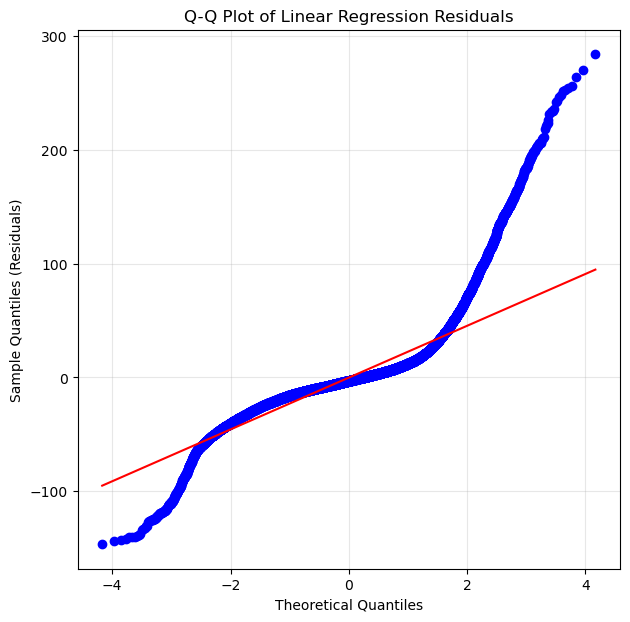

In [146]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Residuals
baseline_residuals = y_test - baseline_preds

# Q-Q Plot
plt.figure(figsize=(7,7))

stats.probplot(baseline_residuals, dist="norm", plot=plt)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles (Residuals)")
plt.title("Q-Q Plot of Linear Regression Residuals")

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
"""
MAE (Mean Absolute Error) = 15.26

On average, your model's prediction is off by about 15.26 days (in either direction — too early or too late), regardless of whether the invoice was actually paid early, on time, or very late.

This is in the same unit as your target (dpd_target — days), which makes it very interpretable for business: "our DPD predictions are typically ~15 days off."
Whether this is "good" depends entirely on business context — if actual DPD values range from -89 to +205 (as we saw earlier), being off by 15 days is moderate; if the business needs precision within a few days, this baseline isn't good enough yet.
RMSE (Root Mean Squared Error) = 25.75

RMSE is also in days, but it penalizes larger errors more heavily than MAE (because it squares the errors before averaging, then takes the square root back).

RMSE > MAE always (mathematically guaranteed) — and here RMSE (25.75) being noticeably higher than MAE (15.26) tells you something important: your model has some predictions that are way off, not just uniformly-moderate errors. If RMSE and MAE were close, errors would be more evenly distributed; the gap here suggests a subset of invoices (probably the very late ones, given the skewed distribution we saw) are being predicted quite poorly.
R² (R-squared) = 0.375

Your model explains about 37.5% of the variance in dpd_target.

R² ranges from 0 (model explains nothing, no better than just predicting the mean) to 1 (perfect prediction).
0.375 is fairly weak — it means 62.5% of the variation in days-late is not being captured by your linear model.
This isn't necessarily alarming on its own — remember, this is your baseline (Linear Regression), specifically chosen as a simple reference point. Linear regression struggles with:
Non-linear relationships (very likely present here, given how skewed/complex payment behavior tends to be)
The heavy-tailed distribution of dpd_target (early payers negative, most people near 0, then a long tail of very late payers)

"""

## A18. LightGBM regression

### LightGBM

In [53]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 7.5 MB/s  0:00:00


In [96]:

import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    min_child_samples = 50
)
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

print("\nLightGBM:")
print(f"MAE:  {mean_absolute_error(y_test, lgb_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgb_preds)):.2f}")
print(f"R²:   {r2_score(y_test, lgb_preds):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013643 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4739
[LightGBM] [Info] Number of data points in the train set: 106197, number of used features: 30
[LightGBM] [Info] Start training from score 11.509638

LightGBM:
MAE:  12.71
RMSE: 22.89
R²:   0.506


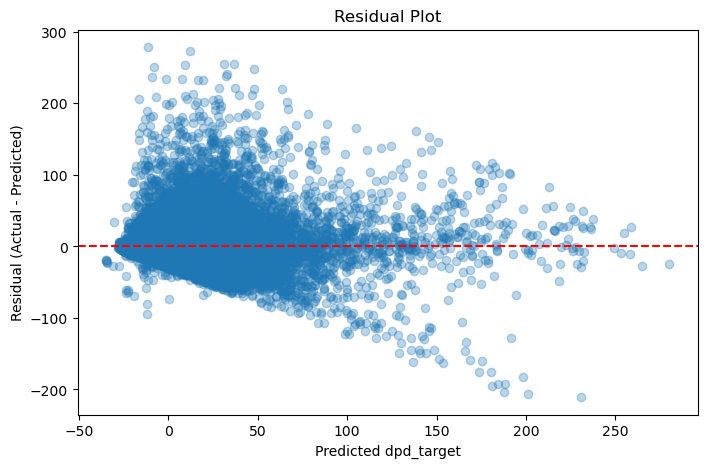

In [98]:
import matplotlib.pyplot as plt

residuals = y_test - lgb_preds

plt.figure(figsize=(8,5))
plt.scatter(lgb_preds, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted dpd_target')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

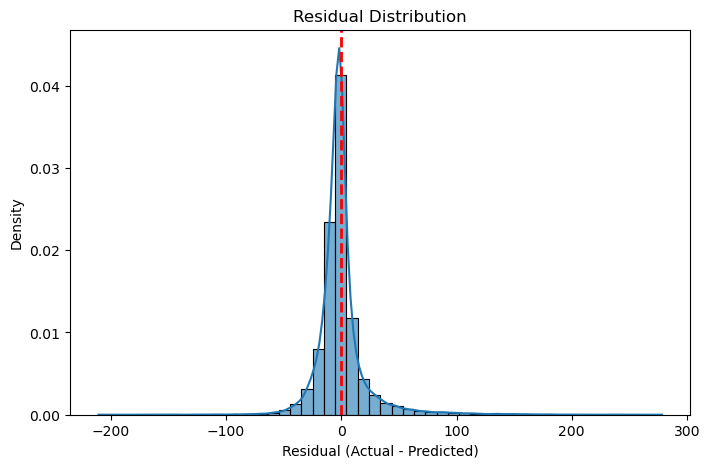

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals
residuals = y_test - lgb_preds

plt.figure(figsize=(8, 5))

# Histogram + KDE
sns.histplot(
    residuals,
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

# Zero residual line
plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution")

plt.show()

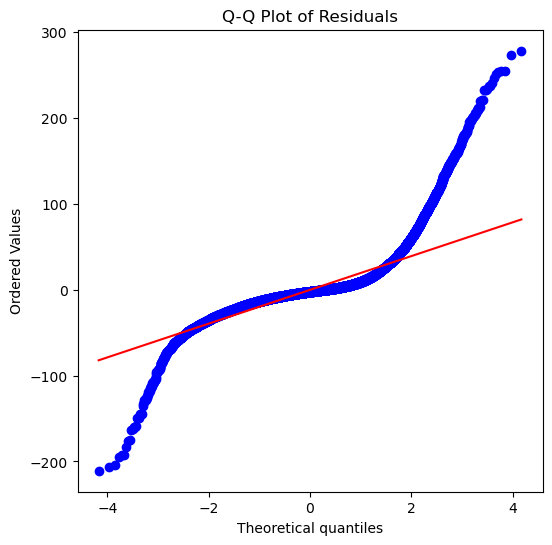

In [145]:
#QUANTILE PLOT
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.show()

## A19. LightGBM feature importance

### FEATURE IMPORTANCE PLOT IN LIGHTGBM

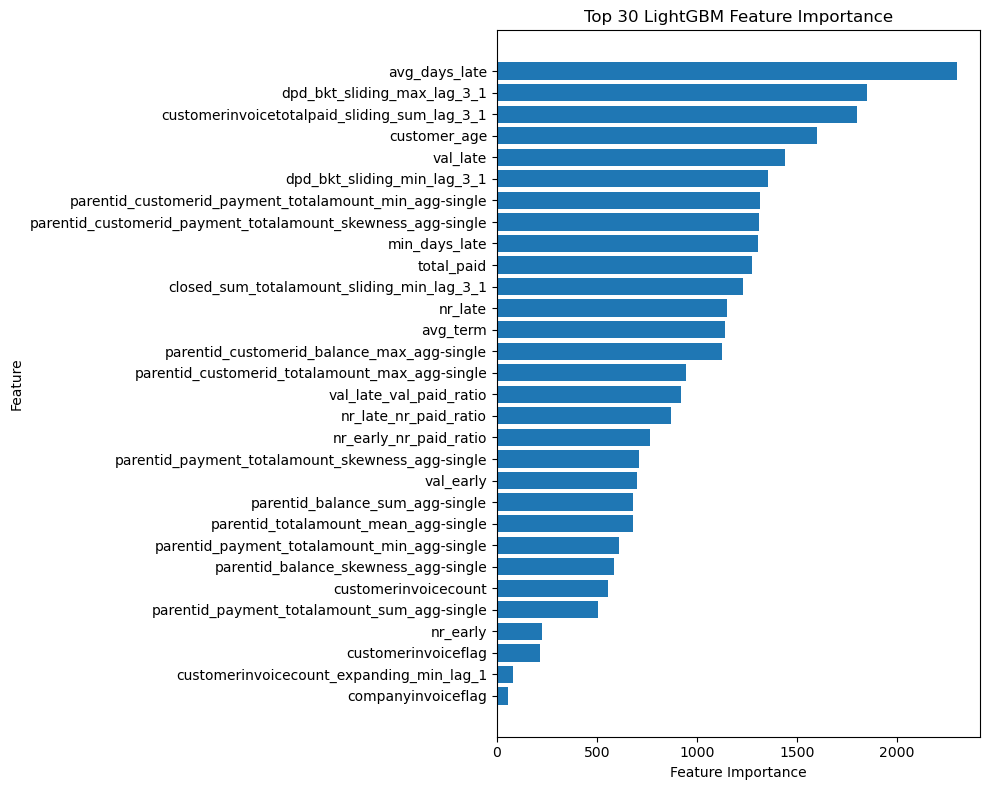

In [142]:
import matplotlib.pyplot as plt

top_n = 30

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"][:top_n][::-1],
    feature_importance["Importance"][:top_n][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 30 LightGBM Feature Importance")

plt.tight_layout()
plt.show()

### FEATURE IMPORTANCE IN LIGHTGBM

In [143]:
import pandas as pd

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

# Calculate percentage contribution
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] /
    feature_importance["Importance"].sum()
) * 100

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Round for readability
feature_importance["Importance (%)"] = feature_importance["Importance (%)"].round(2)

# Display top 30
print(feature_importance.head(30))

                                                        Feature  Importance  \
0                                                 avg_days_late        2300   
1                                   dpd_bkt_sliding_max_lag_3_1        1848   
2                  customerinvoicetotalpaid_sliding_sum_lag_3_1        1799   
3                                                  customer_age        1601   
4                                                      val_late        1438   
5                                   dpd_bkt_sliding_min_lag_3_1        1355   
6        parentid_customerid_payment_totalamount_min_agg-single        1318   
7   parentid_customerid_payment_totalamount_skewness_agg-single        1311   
8                                                 min_days_late        1304   
9                                                    total_paid        1276   
10                   closed_sum_totalamount_sliding_min_lag_3_1        1230   
11                                                  

In [140]:
from scipy.stats import skew, kurtosis

print("Skewness :", skew(residuals))
print("Kurtosis:", kurtosis(residuals, fisher=True))

Skewness : 2.6014499601650534
Kurtosis: 20.32042392760926


In [58]:
df_train['dpd_target'].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

count    106197.000000
mean         11.509638
std          32.645569
min        -106.000000
25%          -5.000000
50%           4.000000
75%          18.000000
90%          43.000000
95%          70.000000
99%         150.000000
max         299.000000
Name: dpd_target, dtype: float64

## A20. Train and test R² comparison

### TRAIN AND TEST R2_SCORE FOR LIGHTGBM

In [102]:
train_preds = lgb_model.predict(X_train)

print("Train R² :", r2_score(y_train, train_preds))
print("Test R²  :", r2_score(y_test, lgb_preds))

Train R² : 0.61390065048657
Test R²  : 0.5058864934306303


## A21. Train-validation split

### Splitting train into train and validation

In [105]:
from sklearn.model_selection import train_test_split

# Split original training set into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Train:", X_tr.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (84957, 30)
Validation: (21240, 30)
Test: (45513, 30)


## A22. XGBoost regression

### XGBOOST

In [116]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train XGBoost model
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=100
)

# Predictions
train_preds = xgb_model.predict(X_tr)
test_preds = xgb_model.predict(X_test)
val_preds = xgb_model.predict(X_val)


# Train Metrics
print("\n========== Train Performance ==========")
print(f"MAE :  {mean_absolute_error(y_tr, train_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_tr, train_preds)):.2f}")
print(f"R²   :  {r2_score(y_tr, train_preds):.3f}")

# Validation Metrics
print("\n========== Validation Performance ==========")
print(f"MAE :  {mean_absolute_error(y_val, val_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_val, val_preds)):.2f}")
print(f"R²   :  {r2_score(y_val, val_preds):.3f}")

# Test Metrics
print("\n========== Test Performance ==========")
print(f"MAE :  {mean_absolute_error(y_test, test_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, test_preds)):.2f}")
print(f"R²   :  {r2_score(y_test, test_preds):.3f}")

[0]	validation_0-rmse:32.39276	validation_1-rmse:32.10947
[100]	validation_0-rmse:23.85718	validation_1-rmse:23.90939
[200]	validation_0-rmse:23.11838	validation_1-rmse:23.51656
[300]	validation_0-rmse:22.68496	validation_1-rmse:23.39761
[400]	validation_0-rmse:22.34766	validation_1-rmse:23.31234
[500]	validation_0-rmse:22.04923	validation_1-rmse:23.26543
[600]	validation_0-rmse:21.78547	validation_1-rmse:23.23383
[700]	validation_0-rmse:21.53444	validation_1-rmse:23.22393
[800]	validation_0-rmse:21.31653	validation_1-rmse:23.21304
[900]	validation_0-rmse:21.11273	validation_1-rmse:23.20948
[999]	validation_0-rmse:20.92188	validation_1-rmse:23.20759

========== Train Performance ==========
MAE :  12.06
RMSE:  20.92
R²   :  0.591

========== Validation Performance ==========
MAE :  12.99
RMSE:  23.21
R²   :  0.488

========== Test Performance ==========
MAE :  12.93
RMSE:  23.14
R²   :  0.495


In [117]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 30
print(feature_importance.head(30))

                                                        Feature  Importance
0                                         nr_late_nr_paid_ratio    0.229741
1                                   dpd_bkt_sliding_min_lag_3_1    0.099873
2                                   dpd_bkt_sliding_max_lag_3_1    0.092371
3                                        nr_early_nr_paid_ratio    0.065596
4                                       val_late_val_paid_ratio    0.049203
5                                                      nr_early    0.045114
6                                                 min_days_late    0.041275
7                                          customerinvoicecount    0.035705
8                                                 avg_days_late    0.030530
9                                                     val_early    0.028363
10                   parentid_customerid_balance_max_agg-single    0.022387
11             parentid_payment_totalamount_skewness_agg-single    0.021257
12       par

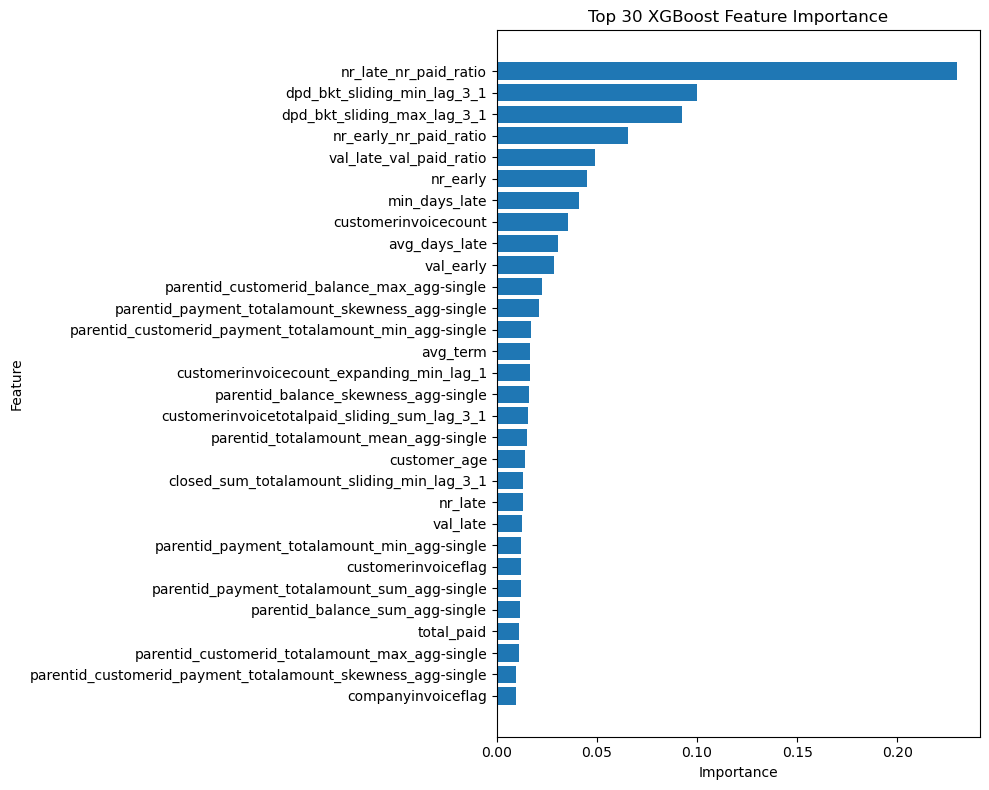

In [118]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:30][::-1],
    feature_importance["Importance"][:30][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 30 XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [119]:
residuals = y_test - test_preds

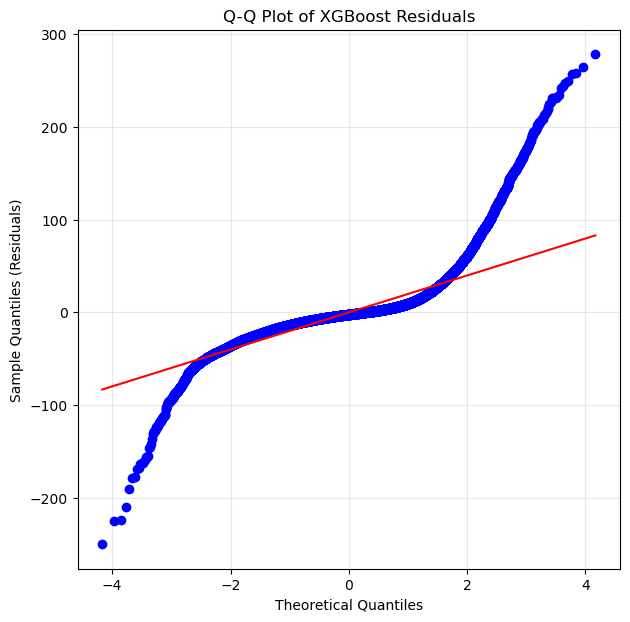

In [120]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(7,7))

stats.probplot(residuals, dist="norm", plot=plt)

plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles (Residuals)")
plt.title("Q-Q Plot of XGBoost Residuals")

plt.grid(True, alpha=0.3)
plt.show()

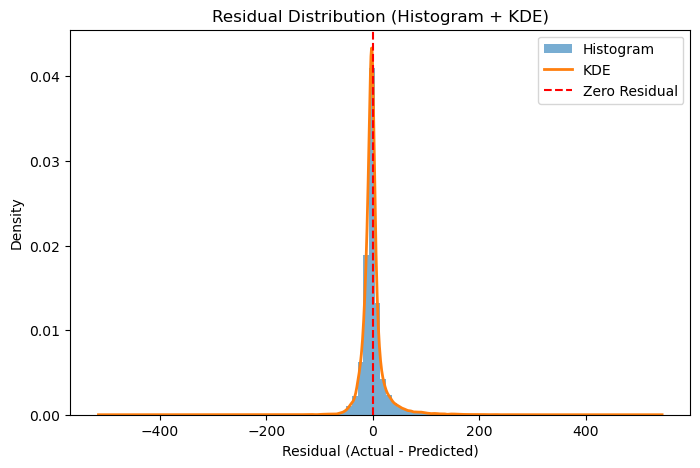

In [121]:
import matplotlib.pyplot as plt
import pandas as pd

# Residuals
residuals = y_test - test_preds

plt.figure(figsize=(8,5))

# Histogram
residuals.plot(
    kind="hist",
    bins=50,
    density=True,
    alpha=0.6,
    label="Histogram"
)

# KDE
residuals.plot(
    kind="kde",
    linewidth=2,
    label="KDE"
)

plt.axvline(0, color="red", linestyle="--", label="Zero Residual")

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution (Histogram + KDE)")
plt.legend()

plt.show()

## A23. Random Forest regression

### RANDOM FOREST

In [134]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_tr, y_tr)

# Predictions
train_preds = rf_model.predict(X_tr)
val_preds = rf_model.predict(X_val)
test_preds = rf_model.predict(X_test)

# Train Metrics
print("\n========== Train Performance ==========")
print(f"MAE :  {mean_absolute_error(y_tr, train_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_tr, train_preds)):.2f}")
print(f"R²   :  {r2_score(y_tr, train_preds):.3f}")

# Validation Metrics
print("\n========== Validation Performance ==========")
print(f"MAE :  {mean_absolute_error(y_val, val_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_val, val_preds)):.2f}")
print(f"R²   :  {r2_score(y_val, val_preds):.3f}")

# Test Metrics
print("\n========== Test Performance ==========")
print(f"MAE :  {mean_absolute_error(y_test, test_preds):.2f}")
print(f"RMSE:  {np.sqrt(mean_squared_error(y_test, test_preds)):.2f}")
print(f"R²   :  {r2_score(y_test, test_preds):.3f}")


========== Train Performance ==========
MAE :  9.99
RMSE:  18.44
R²   :  0.682

========== Validation Performance ==========
MAE :  12.78
RMSE:  23.10
R²   :  0.492

========== Test Performance ==========
MAE :  12.79
RMSE:  23.24
R²   :  0.490


## Approach A recorded results

| Model | Sample | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Linear Regression | Test | 15.26 | 25.75 | 0.375 |
| LightGBM | Test | 12.71 | 22.89 | 0.506 |
| XGBoost | Train | 12.06 | 20.92 | 0.591 |
| XGBoost | Validation | 12.99 | 23.21 | 0.488 |
| XGBoost | Test | 12.93 | 23.14 | 0.495 |
| Random Forest | Train | 9.99 | 18.44 | 0.682 |
| Random Forest | Validation | 12.78 | 23.10 | 0.492 |
| Random Forest | Test | 12.79 | 23.24 | 0.490 |

Among the recorded test results, LightGBM produced the highest R² on the original target at approximately **0.506**.

# Approach B — Regression With Yeo–Johnson Target Transformation

This approach reloads the prepared train and test datasets, applies a **Yeo–Johnson transformation** to `dpd_target`, and evaluates models in the transformed target space.

The transformation is fitted only on the training target and then applied to the test target.

## B1. Imports

In [64]:
import pandas as pd
import numpy as np

## B2. Load prepared training data

In [65]:
df_train=pd.read_csv("outputs/df_train_shuffle_data.csv")

## B3. Load prepared test data

In [66]:
df_test=pd.read_csv("outputs/df_test_shuffle_data.csv")

## B4. Yeo–Johnson target transformation

### TARGET TRANSFORMATION-yeo-johnson

In [67]:
from sklearn.preprocessing import PowerTransformer

# Initialize transformer
pt = PowerTransformer(method="yeo-johnson")

# Fit ONLY on train target
df_train["dpd_target_trans"] = pt.fit_transform(
    df_train[["dpd_target"]]
)

# Transform test target using same transformer
df_test["dpd_target_trans"] = pt.transform(
    df_test[["dpd_target"]]
)

In [68]:
df_train = df_train.drop(columns=["dpd_target"])
df_test = df_test.drop(columns=["dpd_target"])

In [69]:
df_train.shape

(106197, 32)

## B5. Export transformed datasets

In [71]:
df_train.to_csv("outputs/target_transformed_df_train.csv", index=False)

In [72]:
df_test.to_csv("outputs/target_transformed_df_test.csv", index=False)

In [73]:
import os
print(os.getcwd())

C:\Users\Client


In [16]:
cat_cols = [
    'customerinvoiceflag',
    'companyinvoiceflag',
    'dpd_bkt_sliding_min_lag_3_1',
    'dpd_bkt_sliding_max_lag_3_1'
]

num_cols = [
    'customerinvoicetotalpaid_sliding_sum_lag_3_1',
    'val_late',
    'parentid_customerid_payment_totalamount_skewness_agg-single',
    'nr_late_nr_paid_ratio',
    'parentid_payment_totalamount_min_agg-single',
    'parentid_customerid_balance_max_agg-single',
    'customerinvoicecount',
    'nr_early_nr_paid_ratio',
    'nr_early',
    'closed_sum_totalamount_sliding_min_lag_3_1',
    'nr_late',
    'avg_days_late',
    'parentid_totalamount_mean_agg-single',
    'parentid_payment_totalamount_sum_agg-single',
    'customerinvoicecount_expanding_min_lag_1',
    'total_paid',
    'parentid_customerid_totalamount_max_agg-single',
    'parentid_payment_totalamount_skewness_agg-single',
    'parentid_balance_sum_agg-single',
    'parentid_customerid_payment_totalamount_min_agg-single',
    'val_late_val_paid_ratio',
    'parentid_balance_skewness_agg-single',
    'avg_term',
    'val_early',
    'min_days_late',
    'customer_age'
]

## B6. Missing-value and outlier treatment

### MISSING IMPUTATION AND OUTLIER TREATMENT ON FEATURES TO USE

In [17]:
zero_impute_cols = [
    'min_days_late',
    'avg_days_late',
    'parentid_customerid_payment_totalamount_skewness_agg-single',
    'customerinvoicetotalpaid_sliding_sum_lag_3_1',
    'val_late_val_paid_ratio',
    'nr_late_nr_paid_ratio',
    'nr_early_nr_paid_ratio',
    'parentid_balance_skewness_agg-single'
]

# Impute with 0 on both df_train and df_test
df_train[zero_impute_cols] = df_train[zero_impute_cols].fillna(0)
df_test[zero_impute_cols] = df_test[zero_impute_cols].fillna(0)

# Sanity check — confirm no missing values remain in these columns
print("df_train missing after imputation:\n", df_train[zero_impute_cols].isna().sum())
print("\ndf_test missing after imputation:\n", df_test[zero_impute_cols].isna().sum())

df_train missing after imputation:
 min_days_late                                                  0
avg_days_late                                                  0
parentid_customerid_payment_totalamount_skewness_agg-single    0
customerinvoicetotalpaid_sliding_sum_lag_3_1                   0
val_late_val_paid_ratio                                        0
nr_late_nr_paid_ratio                                          0
nr_early_nr_paid_ratio                                         0
parentid_balance_skewness_agg-single                           0
dtype: int64

df_test missing after imputation:
 min_days_late                                                  0
avg_days_late                                                  0
parentid_customerid_payment_totalamount_skewness_agg-single    0
customerinvoicetotalpaid_sliding_sum_lag_3_1                   0
val_late_val_paid_ratio                                        0
nr_late_nr_paid_ratio                                          0
nr_ea

In [18]:
lower_caps = {}
upper_caps = {}

for col in num_cols:
    lower_caps[col] = df_train[col].quantile(0.10)
    upper_caps[col] = df_train[col].quantile(0.90)

# ---- Apply the SAME caps to both train and test ----
for col in num_cols:
    df_train[col] = df_train[col].clip(lower=lower_caps[col], upper=upper_caps[col])
    df_test[col] = df_test[col].clip(lower=lower_caps[col], upper=upper_caps[col])

print("Capping done at 10th and 90th percentile (calculated from df_train, applied to both).")


Capping done at 10th and 90th percentile (calculated from df_train, applied to both).


In [19]:
#IMPUTING MISSING IN CAT COLS
bucket_cols = ['dpd_bkt_sliding_min_lag_3_1', 'dpd_bkt_sliding_max_lag_3_1']

for col in bucket_cols:
    mode_value = df_train[col].mode()[0]   # most frequent value in THIS column
    df_train[col] = df_train[col].fillna(mode_value)
    df_test[col] = df_test[col].fillna(mode_value)   # use train's mode, apply to test

# Sanity check
print(df_train[bucket_cols].isna().sum())
print(df_test[bucket_cols].isna().sum())

dpd_bkt_sliding_min_lag_3_1    0
dpd_bkt_sliding_max_lag_3_1    0
dtype: int64
dpd_bkt_sliding_min_lag_3_1    0
dpd_bkt_sliding_max_lag_3_1    0
dtype: int64


In [20]:
df_train['customerinvoiceflag'] = df_train['customerinvoiceflag'].astype(int)
df_train['companyinvoiceflag'] = df_train['companyinvoiceflag'].astype(int)

df_test['customerinvoiceflag'] = df_test['customerinvoiceflag'].astype(int)
df_test['companyinvoiceflag'] = df_test['companyinvoiceflag'].astype(int)

# Verify
print(df_train[['customerinvoiceflag', 'companyinvoiceflag']].head())
print(df_train[['customerinvoiceflag', 'companyinvoiceflag']].dtypes)

   customerinvoiceflag  companyinvoiceflag
0                    0                   0
1                    1                   0
2                    0                   0
3                    0                   0
4                    1                   0
customerinvoiceflag    int64
companyinvoiceflag     int64
dtype: object


## B7. Modelling setup

In [22]:
# 1. Define final X and y
feature_cols = num_cols + cat_cols  # your final list, excluding target and ID

X_train = df_train[feature_cols]
y_train = df_train['dpd_target_trans']

X_test = df_test[feature_cols]
y_test = df_test['dpd_target_trans']

# 2. Sanity checks
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Any missing left in X_train?", X_train.isna().sum().sum())
print("Any missing left in X_test?", X_test.isna().sum().sum())
print("Columns match:", list(X_train.columns) == list(X_test.columns))

Train shape: (106197, 30) (106197,)
Test shape: (45513, 30) (45513,)
Any missing left in X_train? 0
Any missing left in X_test? 0
Columns match: True


## B8. Linear Regression

### LINEAR MODEL

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = LinearRegression()
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

print("Baseline (Linear Regression):")
print(f"MAE:  {mean_absolute_error(y_test, baseline_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, baseline_preds)):.2f}")
print(f"R²:   {r2_score(y_test, baseline_preds):.3f}")

Baseline (Linear Regression):
MAE:  0.51
RMSE: 0.75
R²:   0.442


## B9. LightGBM regression

### LIGHTGBM MODEL

In [81]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    #subsample=0.8,
    #colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_test)

print("\nLightGBM:")
print(f"MAE:  {mean_absolute_error(y_test, lgb_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgb_preds)):.2f}")
print(f"R²:   {r2_score(y_test, lgb_preds):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014250 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4550
[LightGBM] [Info] Number of data points in the train set: 106197, number of used features: 29
[LightGBM] [Info] Start training from score -0.000000

LightGBM:
MAE:  0.43
RMSE: 0.68
R²:   0.546


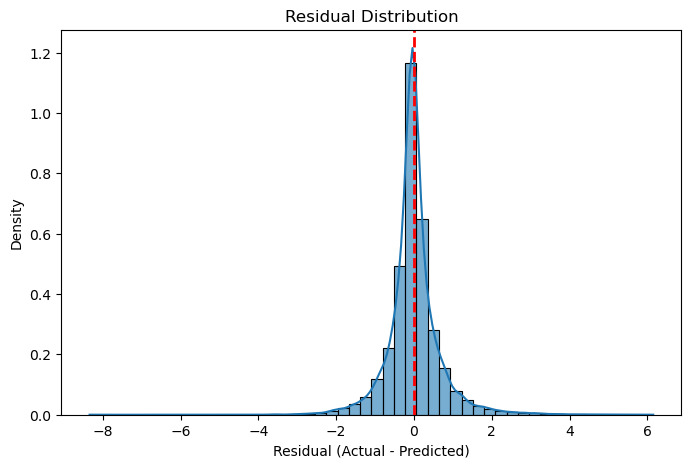

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

# Residuals
residuals = y_test - lgb_preds

plt.figure(figsize=(8, 5))

# Histogram + KDE
sns.histplot(
    residuals,
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

# Zero residual line
plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Density")
plt.title("Residual Distribution")

plt.show()

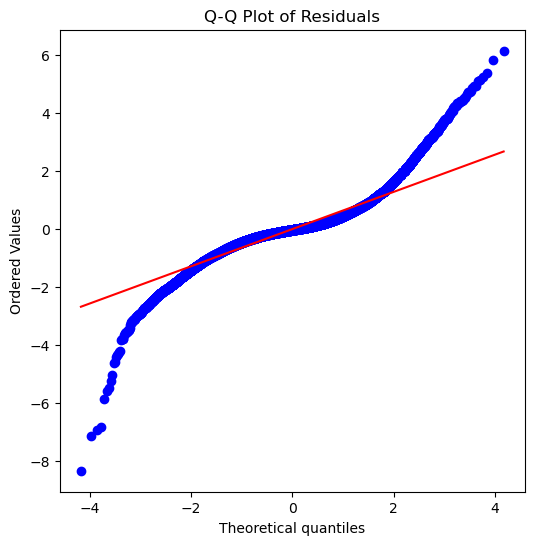

In [83]:
#QUANTILE PLOT
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")
plt.show()

In [84]:
import pandas as pd

# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

# Calculate percentage contribution
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] /
    feature_importance["Importance"].sum()
) * 100

# Sort descending
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Round for readability
feature_importance["Importance (%)"] = feature_importance["Importance (%)"].round(2)

# Display top 30
print(feature_importance.head(30))

                                              Feature  Importance  \
0                         dpd_bkt_sliding_max_lag_3_1        1099   
1                                            avg_term         966   
2                                        customer_age         857   
3                                       avg_days_late         776   
4                         dpd_bkt_sliding_min_lag_3_1         718   
5        customerinvoicetotalpaid_sliding_sum_lag_3_1         675   
6                              nr_early_nr_paid_ratio         658   
7   parentid_customerid_payment_totalamount_min_ag...         651   
8   parentid_customerid_payment_totalamount_skewne...         606   
9                                            val_late         559   
10         parentid_customerid_balance_max_agg-single         542   
11                    parentid_balance_sum_agg-single         527   
12               parentid_balance_skewness_agg-single         488   
13   parentid_payment_totalamount_

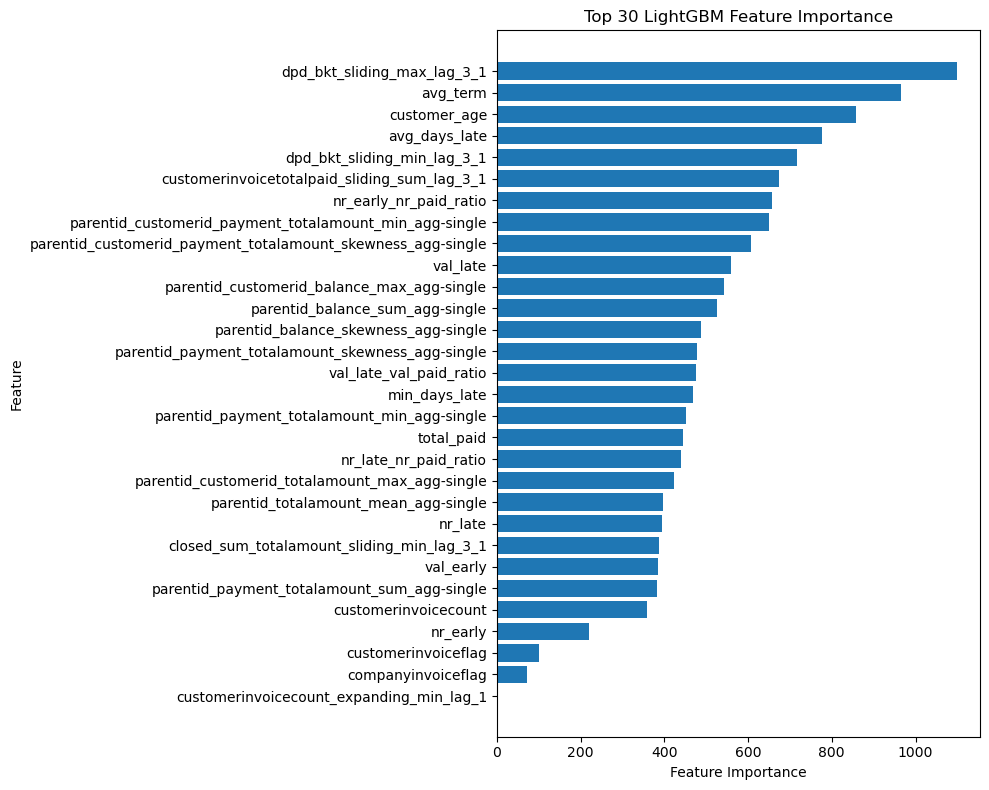

In [85]:
import matplotlib.pyplot as plt

top_n = 30

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"][:top_n][::-1],
    feature_importance["Importance"][:top_n][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 30 LightGBM Feature Importance")

plt.tight_layout()
plt.show()

In [86]:
from scipy.stats import skew, kurtosis

print("Skewness :", skew(residuals))
print("Kurtosis:", kurtosis(residuals, fisher=True))

Skewness : 0.5452026264744968
Kurtosis: 7.878457229718398


## B10. Train and test R² comparison

In [87]:
train_preds = lgb_model.predict(X_train)

print("Train R² :", r2_score(y_train, train_preds))
print("Test R²  :", r2_score(y_test, lgb_preds))

Train R² : 0.5750005471903894
Test R²  : 0.5458548083447798


In [36]:
####

In [43]:
print(y_train.min())
print(y_train.max())
print(y_train.describe())

-10.434278852255813
5.513655331256916
count    1.061970e+05
mean    -2.488977e-17
std      1.000005e+00
min     -1.043428e+01
25%     -4.230918e-01
50%      2.214416e-02
75%      4.293047e-01
max      5.513655e+00
Name: dpd_target_trans, dtype: float64


## Approach B recorded results

| Model | Sample | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Linear Regression | Test, transformed scale | 0.51 | 0.75 | 0.442 |
| LightGBM | Test, transformed scale | 0.43 | 0.68 | 0.546 |

The transformed-target LightGBM model reached a test R² of approximately **0.546** in transformed space.

> MAE and RMSE from Approach B are measured on the transformed target scale and are therefore not directly comparable with the day-based errors from Approach A. A fair business comparison requires inverse-transforming predictions back to the original `dpd_target` scale.

# Model Comparison and Interpretation

- Target transformation improved the recorded LightGBM R² from approximately **0.506** to **0.546**.
- This suggests that reducing target skew may have helped the model explain more variation.
- The transformed model's MAE and RMSE cannot be interpreted as days until predictions are inverse-transformed.
- For deployment, predictions should be converted back to the original days-past-due scale before reporting business metrics.

# Future Improvements

- Inverse-transform transformed-target predictions before calculating MAE and RMSE in days
- Use one reproducible preprocessing pipeline
- Fit imputation, outlier treatment, and encoding only on training data
- Add cross-validation
- Compare LightGBM, XGBoost, Random Forest, CatBoost, and regularised linear models
- Tune hyperparameters systematically
- Analyse residuals by customer and invoice segments
- Add SHAP explanations
- Deploy a Streamlit interface